# 00 — Exploración de datos crudos (CICIDS2017 corregido)

**Objetivo:** conocer los 5 CSV crudos ANTES de que `vae_nids.data.pipeline` los sanitice,
divida y escale. Aquí se conservan TODAS las columnas (incl. `Flow ID`, IPs, `Timestamp`,
puertos) para poder verificar a mano las decisiones de preprocesamiento documentadas en el
README, y detectar cualquier problema que el pipeline no esté contemplando.

Kernel: selecciona el intérprete de `.venv` (el proyecto está instalado en modo editable,
así que `import vae_nids` funciona directo sin tocar `sys.path`).

In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vae_nids import config as cfg

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


## 1. Inventario de archivos crudos

In [2]:
for fname in cfg.CSV_FILES:
    fpath = cfg.DATA_DIR / fname
    size_mb = fpath.stat().st_size / 1024**2
    print(f"{fname:30s} {size_mb:8.1f} MB")


Monday-WorkingHours.csv           198.6 MB
Tuesday-WorkingHours.csv          170.2 MB
Wednesday-WorkingHours.csv        278.0 MB
Thursday-WorkingHours.csv         179.0 MB
Friday-WorkingHours.csv           269.5 MB


## 2. Consistencia de columnas entre días

Antes de cargar todo, comparamos solo el header de cada CSV (rápido) para detectar
diferencias de nombres de columnas entre días — problema conocido en versiones crudas
de CICIDS2017.

In [3]:
columns_by_day = {}
for fname in cfg.CSV_FILES:
    day = fname.split("-")[0]
    header = pd.read_csv(cfg.DATA_DIR / fname, nrows=0)
    header.columns = header.columns.str.strip()
    columns_by_day[day] = list(header.columns)
    print(f"{day:10s} {len(header.columns)} columnas")

sets = {day: set(cols) for day, cols in columns_by_day.items()}
common = set.intersection(*sets.values())
union = set.union(*sets.values())

print(f"\nColumnas comunes a los 5 días: {len(common)}")
print(f"Columnas en la unión de los 5 días: {len(union)}")

if union != common:
    print("\nDiferencias por día (columnas que le faltan respecto a la unión):")
    for day, s in sets.items():
        missing = union - s
        if missing:
            print(f"  {day}: {sorted(missing)}")
else:
    print("Los 5 días tienen exactamente las mismas columnas -> concat directo es seguro.")


Monday     84 columnas
Tuesday    84 columnas
Wednesday  84 columnas
Thursday   84 columnas
Friday     84 columnas

Columnas comunes a los 5 días: 84
Columnas en la unión de los 5 días: 84
Los 5 días tienen exactamente las mismas columnas -> concat directo es seguro.


## 3. Carga completa (conservando TODAS las columnas, incl. IDs/puertos)

`pipeline.py` descarta `IDENTIFIER_COLS`/`PORT_COLS` y castea a `float32` ya en la lectura
para mantener el pico de memoria bajo. Aquí, a propósito, **no** hacemos eso: queremos ver
la data tal cual llega, para poder inspeccionar IPs/puertos antes de que el pipeline los
elimine.

Los 5 CSV pesan en total ~1.1 GB; cargados con los dtypes por defecto de pandas
(float64/int64) pueden ocupar varias veces eso en RAM. Si tu máquina no lo aguanta, pon
`N_ROWS_PER_DAY` en un entero (p. ej. `300_000`) para trabajar con una muestra.

In [4]:
N_ROWS_PER_DAY = None  # None = cargar todo; o un entero para muestrear rápido

def load_raw_day(fname: str, nrows=None) -> pd.DataFrame:
    day = fname.split("-")[0]
    df = pd.read_csv(cfg.DATA_DIR / fname, nrows=nrows, low_memory=False)
    df.columns = df.columns.str.strip()
    df["Day"] = day
    return df

frames = []
for fname in cfg.CSV_FILES:
    df_day = load_raw_day(fname, nrows=N_ROWS_PER_DAY)
    print(f"[load] {fname:30s} -> {len(df_day):>10,} filas")
    frames.append(df_day)

raw = pd.concat(frames, ignore_index=True)
del frames
print(f"\n[load] total: {len(raw):,} filas x {raw.shape[1]} columnas")


[load] Monday-WorkingHours.csv        ->    371,749 filas
[load] Tuesday-WorkingHours.csv       ->    322,003 filas
[load] Wednesday-WorkingHours.csv     ->    496,779 filas
[load] Thursday-WorkingHours.csv      ->    362,368 filas
[load] Friday-WorkingHours.csv        ->    547,915 filas

[load] total: 2,100,814 filas x 85 columnas


## 4. Forma general, tipos de dato y memoria

In [5]:
print(raw.shape)
raw.dtypes.value_counts()


(2100814, 85)


float64    45
int64      34
str         6
Name: count, dtype: int64

In [6]:
mem_mb = raw.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria en RAM: {mem_mb:,.1f} MB")


Memoria en RAM: 1,557.7 MB


In [7]:
# Columnas no numéricas -- esperamos: Flow ID, Src IP, Dst IP, Timestamp, Label, Day
non_numeric = raw.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric


['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Day']

## 5. Duplicados

In [8]:
n_dupes_full = raw.duplicated().sum()
print(f"Filas 100% duplicadas (todas las columnas): {n_dupes_full:,} ({n_dupes_full/len(raw):.3%})")

id_like = [c for c in ["Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Timestamp"] if c in raw.columns]
n_dupes_flow = raw.duplicated(subset=id_like).sum() if id_like else None
print(f"Filas duplicadas por (Flow ID/IPs/Puertos/Timestamp): {n_dupes_flow:,}")


Filas 100% duplicadas (todas las columnas): 3,143 (0.150%)
Filas duplicadas por (Flow ID/IPs/Puertos/Timestamp): 9,186


## 6. Etiquetas (`Label`) — la variable más importante del proyecto

In [9]:
label_counts = raw[cfg.LABEL_COL].value_counts()
label_pct = (label_counts / len(raw) * 100).round(4)
pd.DataFrame({"count": label_counts, "pct_%": label_pct})


,count,pct_%
Label,,
BENIGN,1657693,78.9072
PortScan,159151,7.5757
DoS Hulk,158469,7.5432
DDoS,95123,4.5279
DoS GoldenEye,7567,0.3602
DoS slowloris,4001,0.1904
FTP-Patator,3973,0.1891
DoS Slowhttptest - Attempted,3369,0.1604
SSH-Patator,2980,0.1418


### 6.1 Separadores no estándar en `"X - Attempted"`

`pipeline.build_label_taxonomy` hace `str.replace(" - Attempted", "", regex=False)` con un
guion normal (`-`). Si algún label usa en-dash/em-dash u otro separador, ese replace no
haría match y `attack_family` quedaría mal derivado para esa clase.

In [10]:
unique_labels = raw[cfg.LABEL_COL].unique()
found_any = False
for lbl in sorted(unique_labels):
    dashes = re.findall(r"[\u2010-\u2015\-]", lbl)
    if dashes and set(dashes) - {"-"}:
        print(f"POSIBLE separador no estándar: {lbl!r}")
        found_any = True
if not found_any:
    print("OK: todos los labels usan guion '-' estándar (ASCII 0x2D).")


OK: todos los labels usan guion '-' estándar (ASCII 0x2D).


### 6.2 Distribución de `Label` por día

In [11]:
label_by_day = pd.crosstab(raw["Day"], raw[cfg.LABEL_COL])
label_by_day


Label,BENIGN,Bot,Bot - Attempted,DDoS,DoS GoldenEye,DoS GoldenEye - Attempted,DoS Hulk,DoS Hulk - Attempted,DoS Slowhttptest,DoS Slowhttptest - Attempted,DoS slowloris,DoS slowloris - Attempted,FTP-Patator,FTP-Patator - Attempted,Heartbleed,Infiltration,Infiltration - Attempted,PortScan,SSH-Patator,SSH-Patator - Attempted,Web Attack - Brute Force,Web Attack - Brute Force - Attempted,Web Attack - Sql Injection,Web Attack - XSS,Web Attack - XSS - Attempted
Day,,,,,,,,,,,,,,,,,,,,,,,,,
Friday,291433,738,1470,95123,0,0,0,0,0,0,0,0,0,0,0,0,0,159151,0,0,0,0,0,0,0
Monday,371749,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday,360264,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,16,0,0,0,151,1214,12,27,652
Tuesday,315031,0,0,0,0,0,0,0,0,0,0,0,3973,11,0,0,0,0,2980,8,0,0,0,0,0
Wednesday,319216,0,0,0,7567,80,158469,593,1742,3369,4001,1731,0,0,11,0,0,0,0,0,0,0,0,0,0


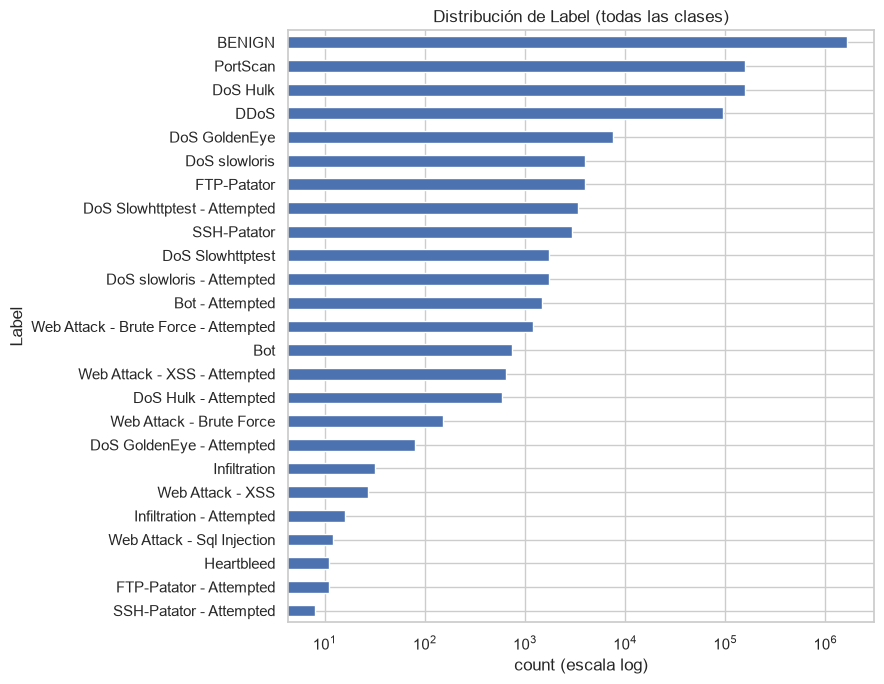

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
label_counts.sort_values().plot(kind="barh", ax=ax, logx=True)
ax.set_xlabel("count (escala log)")
ax.set_title("Distribución de Label (todas las clases)")
plt.tight_layout()
plt.show()


## 7. Nulos e infinitos (antes de sanitizar)

El README documenta ~0.04% de filas eliminadas por división por cero en
`Flow Bytes/s`, `Flow Packets/s`, `Flow IAT *`. Lo verificamos aquí directamente sobre
crudo, y vemos a qué labels afecta (para confirmar que no se concentra desproporcionadamente
en una sola familia de ataque).

In [13]:
numeric_cols = raw.select_dtypes(include=[np.number]).columns

n_inf = np.isinf(raw[numeric_cols]).sum()
n_inf = n_inf[n_inf > 0].sort_values(ascending=False)
print("Columnas con valores infinitos:")
n_inf


Columnas con valores infinitos:


Flow Packets/s    793
Flow Bytes/s      191
dtype: int64

In [14]:
n_null = raw[numeric_cols].isna().sum()
n_null = n_null[n_null > 0].sort_values(ascending=False)
print("Columnas con NaN nativos (antes de convertir inf->nan):")
n_null


Columnas con NaN nativos (antes de convertir inf->nan):


Flow Bytes/s     602
Flow IAT Mean    252
Flow IAT Std     252
Flow IAT Max     252
Flow IAT Min     252
dtype: int64

In [15]:
rows_bad = np.isinf(raw[numeric_cols]).any(axis=1) | raw[numeric_cols].isna().any(axis=1)
print(f"Filas afectadas por nulos/infinitos: {rows_bad.sum():,} ({rows_bad.mean():.4%})")
print("\nDistribución de Label en las filas afectadas:")
raw.loc[rows_bad, cfg.LABEL_COL].value_counts()


Filas afectadas por nulos/infinitos: 793 (0.0377%)

Distribución de Label en las filas afectadas:


Label
BENIGN                          624
PortScan                        128
DoS slowloris - Attempted        25
DoS Hulk - Attempted             14
DoS Slowhttptest - Attempted      2
Name: count, dtype: int64

## 8. IPs y puertos (excluidos del modelo, pero relevantes para EDA)

In [16]:
for col in ["Src IP", "Dst IP"]:
    if col in raw.columns:
        print(f"{col}: {raw[col].nunique():,} valores únicos")
        print(raw[col].value_counts().head(10))
        print()


Src IP: 48 valores únicos
Src IP
172.16.0.1       442098
192.168.10.3     296086
192.168.10.8     204671
192.168.10.5     151027
192.168.10.9     136846
192.168.10.15    130766
192.168.10.14    125219
192.168.10.12    125023
192.168.10.17    106758
192.168.10.16    103735
Name: count, dtype: int64

Dst IP: 19,045 valores únicos
Dst IP
192.168.10.3      681532
192.168.10.50     457083
192.168.10.1      294108
192.168.10.5       12179
178.255.83.1       10146
72.21.91.29        10029
192.168.10.25       8247
192.168.10.15       8173
192.168.10.14       8165
162.208.20.178      8091
Name: count, dtype: int64



In [17]:
for col in ["Src Port", "Dst Port"]:
    if col in raw.columns:
        print(f"{col}: {raw[col].nunique():,} valores únicos")


Src Port: 64,639 valores únicos
Dst Port: 5,434 valores únicos


Chequeo de la afirmación del README: *"las IPs de atacante/víctima son fijas durante
toda la simulación en CICIDS2017"*. Si es cierto, cada familia de ataque debería tener muy
pocas IPs origen distintas.

In [18]:
if "Src IP" in raw.columns:
    attack_mask = raw[cfg.LABEL_COL] != "BENIGN"
    ip_by_label = (
        raw.loc[attack_mask]
        .groupby(cfg.LABEL_COL)["Src IP"]
        .nunique()
        .sort_values(ascending=False)
    )
    print("IPs origen únicas por tipo de ataque (bajo = confirma IP ~fija):")
    ip_by_label


IPs origen únicas por tipo de ataque (bajo = confirma IP ~fija):


## 9. Estadística descriptiva de las features numéricas

In [19]:
feature_cols_preview = [c for c in raw.columns if c not in id_like + ["Day", cfg.LABEL_COL]]
desc = raw[feature_cols_preview].describe().T
desc


c:\Users\user\Desktop\vae-latent-geometry-nids\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\user\Desktop\vae-latent-geometry-nids\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Protocol,2100814.0,1.122952e+01,5.500536e+00,0.0,6.0,6.0,17.0,1.700000e+01
Flow Duration,2100814.0,1.243250e+07,3.102224e+07,-13.0,247.0,61788.0,4379509.5,1.200000e+08
Total Fwd Packet,2100814.0,1.251571e+01,8.702024e+02,0.0,2.0,2.0,8.0,2.197590e+05
Total Bwd packets,2100814.0,1.420293e+01,1.157754e+03,0.0,2.0,2.0,6.0,2.919220e+05
Total Length of Fwd Packet,2100814.0,5.703350e+02,1.045976e+04,0.0,48.0,80.0,358.0,1.287025e+07
...,...,...,...,...,...,...,...,...
Active Min,2100814.0,9.244057e+04,7.005675e+05,0.0,0.0,0.0,0.0,1.100975e+08
Idle Mean,2100814.0,4.431157e+06,1.388999e+07,0.0,0.0,0.0,0.0,1.199997e+08
Idle Std,2100814.0,2.895880e+05,2.657956e+06,0.0,0.0,0.0,0.0,7.691483e+07
Idle Max,2100814.0,4.674519e+06,1.449085e+07,0.0,0.0,0.0,0.0,1.199997e+08


Columnas con valores negativos donde no deberían existir (duraciones, conteos, bytes) —
otro problema documentado de CICIDS2017 crudo (p. ej. `Flow IAT Min` negativo).

In [20]:
neg_counts = (raw[feature_cols_preview] < 0).sum()
neg_counts = neg_counts[neg_counts > 0].sort_values(ascending=False)
print("Columnas con valores negativos:")
neg_counts


Columnas con valores negativos:


Flow IAT Min      2922
Flow Duration       31
Flow Packets/s      31
Flow IAT Mean       31
Flow IAT Max        31
dtype: int64

## 10. Notas / hallazgos

_(completar a mano a medida que se revisan las salidas de arriba)_

- Columnas inconsistentes entre días:
- Labels con separador no estándar:
- % de filas con nulos/infinitos y si se concentra en alguna familia:
- ¿IPs realmente fijas por familia de ataque?
- Columnas con valores negativos inesperados:
- Otras anomalías:
